# NFL 4th Down Decision Analysis
## Defensive Analysis

This notebook flips the perspective from offense to defense — analyzing which NFL defenses are most effective at stopping 4th down conversion attempts. We examine defensive personnel, coverage type, box counts, and which defensive coordinators and teams hold offenses to the lowest conversion rates when they go for it.

---

### Setup & Data Load
Load the processed dataset and filter to go-for-it plays.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
processed_path = os.path.join(project_root, "data", "processed")
figures_path = os.path.join(project_root, "outputs", "figures")

fourth_downs = pd.read_parquet(os.path.join(processed_path, "fourth_downs.parquet"))
go_for_it = fourth_downs[fourth_downs['decision'] == 'go'].copy()
go_for_it['converted'] = go_for_it['fourth_down_converted'].astype(int)
go_for_it['stopped'] = 1 - go_for_it['converted']

print(f"Go-for-it plays: {len(go_for_it)}")
print(f"\nDefensive columns available:")
print([col for col in go_for_it.columns if any(
    word in col.lower() for word in ['defense', 'box', 'coverage', 'zone', 'man']
)])

Go-for-it plays: 7058

Defensive columns available:
['defenders_in_box', 'defense_personnel', 'defense_man_zone_type', 'defense_coverage_type']


Dataset loaded with 4 defensive columns available for analysis:

- `defenders_in_box` — number of defenders in the box at the snap
- `defense_personnel` — defensive personnel grouping
- `defense_man_zone_type` — whether the defense is playing man or zone coverage
- `defense_coverage_type` — specific coverage shell (Cover 1, Cover 2, Cover 3, etc.)

We also have `defteam` which allows us to analyze stop rates by team. Let's start by exploring what each defensive column contains.

---

### Explore Defensive Data
Check the distribution of each defensive column before building visualizations.

In [2]:
print("Coverage type breakdown:")
print(go_for_it['defense_coverage_type'].value_counts())
print(f"Missing: {go_for_it['defense_coverage_type'].isna().sum()}")

print("\nMan/Zone breakdown:")
print(go_for_it['defense_man_zone_type'].value_counts())
print(f"Missing: {go_for_it['defense_man_zone_type'].isna().sum()}")

print("\nDefense personnel breakdown:")
print(go_for_it['defense_personnel'].value_counts().head(10))
print(f"Missing: {go_for_it['defense_personnel'].isna().sum()}")

Coverage type breakdown:
defense_coverage_type
COVER_1    1392
COVER_3     551
COVER_0     506
COVER_2     399
COVER_4     283
2_MAN       213
COVER_6     116
COMBO        50
COVER_9      48
PREVENT      46
BLOWN         7
Name: count, dtype: int64
Missing: 3447

Man/Zone breakdown:
defense_man_zone_type
MAN_COVERAGE     2111
ZONE_COVERAGE    1500
                  882
Name: count, dtype: int64
Missing: 2565

Defense personnel breakdown:
defense_personnel
4 DL, 2 LB, 5 DB    1034
4 DL, 3 LB, 4 DB     514
3 DL, 3 LB, 5 DB     499
2 DL, 4 LB, 5 DB     497
2 DL, 3 LB, 6 DB     319
3 DL, 4 LB, 4 DB     263
4 DL, 1 LB, 6 DB     233
3 DL, 2 LB, 6 DB     230
1 DL, 4 LB, 6 DB     122
5 DL, 2 LB, 4 DB      84
Name: count, dtype: int64
Missing: 28


Good data availability across defensive columns with some notable missing value patterns:

- `defense_coverage_type` — 3,447 missing (49%), only available for passing situations where coverage is trackable
- `defense_man_zone_type` — 2,565 missing (36%), same limitation
- `defense_personnel` — only 28 missing, very clean

Coverage data is missing for roughly half of plays which is expected — tracking coverage type requires film review and is not available for all plays in the dataset. We'll analyze what we have while noting this limitation.

---

### Stop Rate by Coverage Type
Which coverage shells are most effective at stopping 4th down conversions?

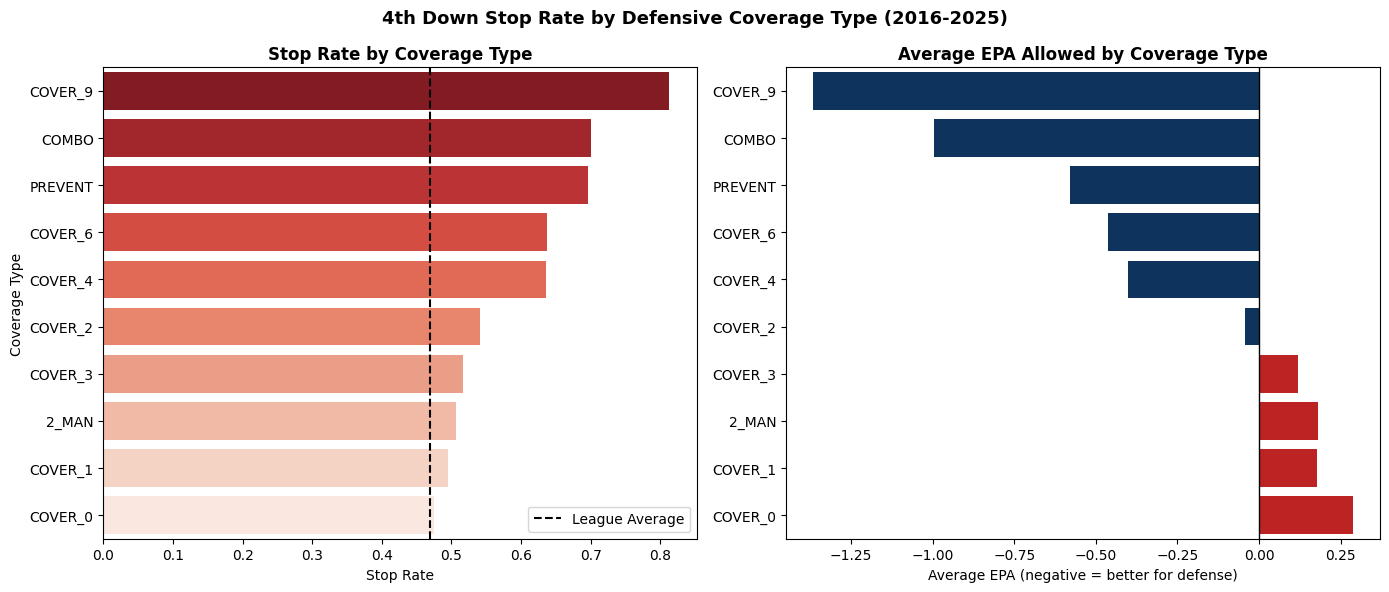

defense_coverage_type  attempts  stop_rate   avg_epa
              COVER_9        48   0.812500 -1.365872
                COMBO        50   0.700000 -0.994661
              PREVENT        46   0.695652 -0.579531
              COVER_6       116   0.637931 -0.463109
              COVER_4       283   0.636042 -0.400188
              COVER_2       399   0.541353 -0.042389
              COVER_3       551   0.517241  0.118064
                2_MAN       213   0.507042  0.181027
              COVER_1      1392   0.494971  0.178489
              COVER_0       506   0.474308  0.287487


In [3]:
# Stop rate by coverage type (minimum 40 attempts)
coverage_conv = go_for_it.dropna(subset=['defense_coverage_type']).groupby('defense_coverage_type').agg(
    attempts=('stopped', 'count'),
    stop_rate=('stopped', 'mean'),
    avg_epa=('epa', 'mean')
).reset_index()

coverage_conv = coverage_conv[coverage_conv['attempts'] >= 40].sort_values('stop_rate', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Stop rate
sns.barplot(data=coverage_conv, x='stop_rate', y='defense_coverage_type',
            hue='defense_coverage_type', palette='Reds_r', legend=False, ax=axes[0])
axes[0].axvline(x=go_for_it['stopped'].mean(), color='black', linestyle='--', linewidth=1.5, label='League Average')
axes[0].set_title('Stop Rate by Coverage Type', fontweight='bold')
axes[0].set_xlabel('Stop Rate')
axes[0].set_ylabel('Coverage Type')
axes[0].legend()

# EPA allowed
colors = ['#D50A0A' if x > 0 else '#013369' for x in coverage_conv['avg_epa']]
sns.barplot(data=coverage_conv, x='avg_epa', y='defense_coverage_type',
            hue='defense_coverage_type',
            palette=dict(zip(coverage_conv['defense_coverage_type'], colors)),
            legend=False, ax=axes[1])
axes[1].axvline(x=0, color='black', linewidth=1)
axes[1].set_title('Average EPA Allowed by Coverage Type', fontweight='bold')
axes[1].set_xlabel('Average EPA (negative = better for defense)')
axes[1].set_ylabel('')

plt.suptitle('4th Down Stop Rate by Defensive Coverage Type (2016-2025)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(figures_path, "stop_rate_by_coverage.png"), dpi=150, bbox_inches='tight')
plt.show()

print(coverage_conv.to_string(index=False))

![Stop Rate by Coverage Type](../outputs/figures/stop_rate_by_coverage.png)

The coverage data reveals a clear hierarchy of defensive effectiveness on 4th down go-for-it attempts:

**Most effective coverages (high stop rate, negative EPA):**
- **Cover 9 (81% stop rate, -1.37 EPA)** — the most effective coverage in the dataset by a wide margin. Cover 9 is a specialized pressure coverage that overwhelms offenses with multiple pass rushers while maintaining coverage integrity
- **Combo (70% stop rate, -0.99 EPA)** — mixed coverage concepts that disguise defensive intentions are highly effective at stopping go-for-it attempts
- **Prevent (70% stop rate, -0.58 EPA)** — surprisingly effective, suggesting teams in prevent are successfully trading deep coverage for short yardage stops
- **Cover 6 (64% stop rate, -0.46 EPA)** and **Cover 4 (64% stop rate, -0.40 EPA)** — two-high safety coverages that limit explosive plays while maintaining run support

**Least effective coverages (low stop rate, positive EPA allowed):**
- **Cover 0 (47% stop rate, +0.29 EPA)** — all-out blitz with no deep safety is the easiest coverage to convert against. Offenses gain significant EPA when they successfully attack Cover 0
- **Cover 1 (49% stop rate, +0.18 EPA)** — man coverage with a single high safety is below league average
- **2 Man (51% stop rate, +0.18 EPA)** — man coverage with two safeties performs only marginally better

**The key tactical insight:** aggressive man coverages (Cover 0, Cover 1) that are designed to stop the run and create pressure actually allow higher conversion rates than zone coverages with two high safeties. Defenses blitzing on 4th down are giving offenses better odds of converting.

---

### Stop Rate by Man vs Zone
Does the fundamental man/zone distinction matter more than specific coverage shell?

/tmp/ipykernel_27152/2158375945.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=manz_conv, x='defense_man_zone_type', y='stop_rate',
/tmp/ipykernel_27152/2158375945.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=manz_conv, x='defense_man_zone_type', y='avg_epa',


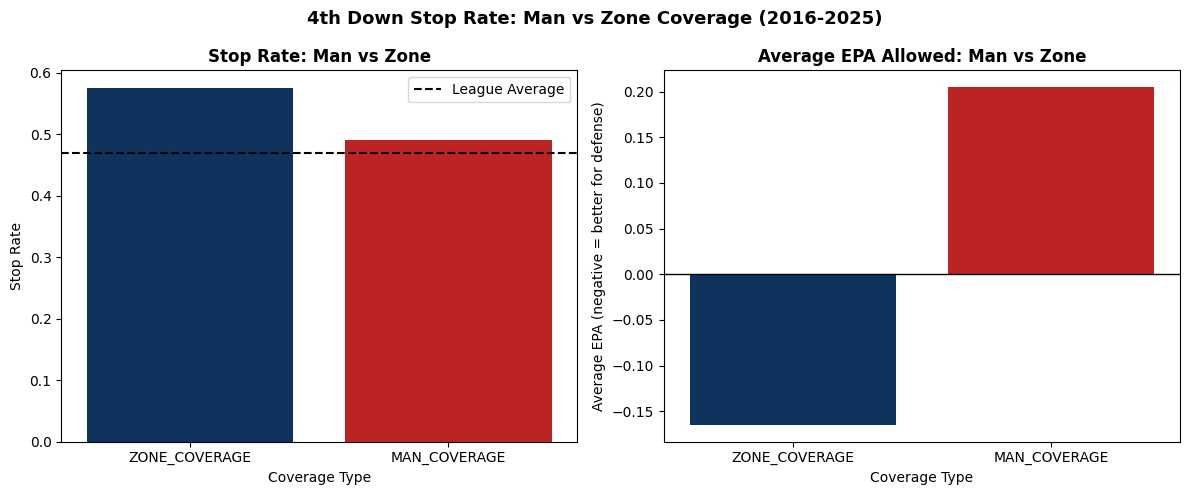

defense_man_zone_type  attempts  stop_rate   avg_epa
        ZONE_COVERAGE      1500   0.575333 -0.164901
         MAN_COVERAGE      2111   0.491236  0.204872


In [4]:
# Man vs Zone stop rate
manz_conv = go_for_it.dropna(subset=['defense_man_zone_type']).groupby('defense_man_zone_type').agg(
    attempts=('stopped', 'count'),
    stop_rate=('stopped', 'mean'),
    avg_epa=('epa', 'mean')
).reset_index().sort_values('stop_rate', ascending=False)

# Remove empty string category
manz_conv = manz_conv[manz_conv['defense_man_zone_type'].isin(['MAN_COVERAGE', 'ZONE_COVERAGE'])]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Stop rate
sns.barplot(data=manz_conv, x='defense_man_zone_type', y='stop_rate',
            palette={'MAN_COVERAGE': '#D50A0A', 'ZONE_COVERAGE': '#013369'}, ax=axes[0])
axes[0].axhline(y=go_for_it['stopped'].mean(), color='black', linestyle='--', linewidth=1.5, label='League Average')
axes[0].set_title('Stop Rate: Man vs Zone', fontweight='bold')
axes[0].set_xlabel('Coverage Type')
axes[0].set_ylabel('Stop Rate')
axes[0].legend()

# EPA
sns.barplot(data=manz_conv, x='defense_man_zone_type', y='avg_epa',
            palette={'MAN_COVERAGE': '#D50A0A', 'ZONE_COVERAGE': '#013369'}, ax=axes[1])
axes[1].axhline(y=0, color='black', linewidth=1)
axes[1].set_title('Average EPA Allowed: Man vs Zone', fontweight='bold')
axes[1].set_xlabel('Coverage Type')
axes[1].set_ylabel('Average EPA (negative = better for defense)')

plt.suptitle('4th Down Stop Rate: Man vs Zone Coverage (2016-2025)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(figures_path, "man_vs_zone_stop_rate.png"), dpi=150, bbox_inches='tight')
plt.show()

print(manz_conv.to_string(index=False))

![Man vs Zone Stop Rate](../outputs/figures/man_vs_zone_stop_rate.png)

The man vs zone distinction is one of the clearest findings in this notebook:

- **Zone coverage (58% stop rate, -0.16 EPA)** — stops 4th down conversions above league average and generates negative EPA, meaning the defense wins the play on average
- **Man coverage (49% stop rate, +0.20 EPA)** — stops conversions at below league average and allows positive EPA, meaning the offense wins the play on average

This is a significant and actionable finding. Defenses playing zone on 4th down stop conversions at a 9 percentage point higher rate than man coverage, and the EPA gap of 0.36 points per play is substantial over a full season of 4th down attempts.

Combined with the coverage type findings, the data makes a strong case that **zone coverage — particularly two-high shells like Cover 4 and Cover 6 — is the optimal defensive strategy on 4th down go-for-it attempts**. Yet many defensive coordinators default to man coverage and blitz packages in high-pressure short yardage situations, which the data shows is counterproductive.

---

### Stop Rate by Defensive Team
Which NFL teams are best at stopping 4th down conversion attempts?

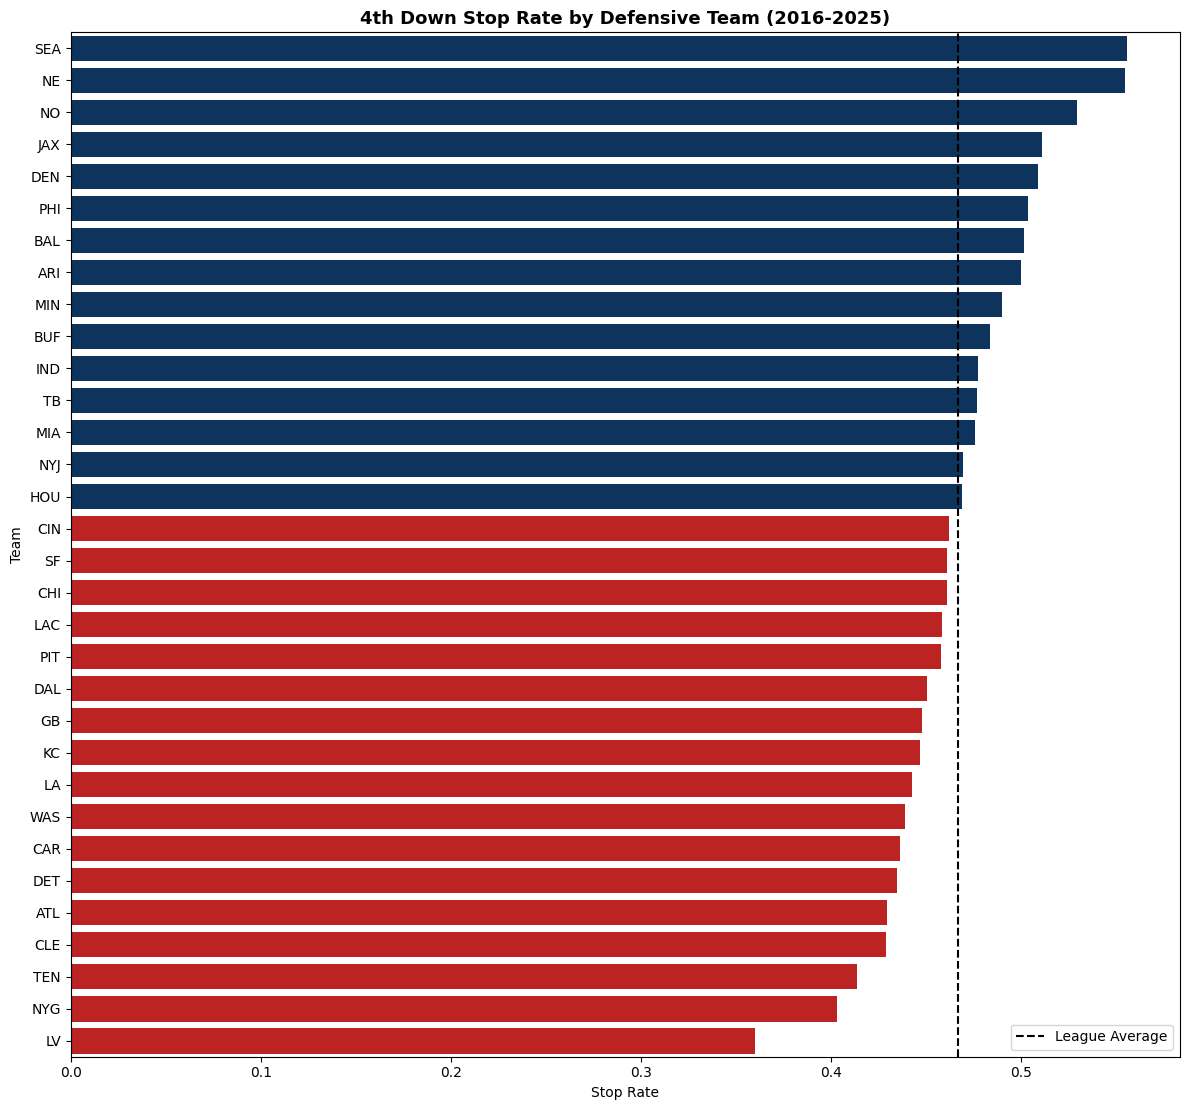

Total qualified teams: 32
League average stop rate: 46.70%

Top 5 defenses:
defteam  attempts_faced  stop_rate  avg_epa_allowed
    SEA             241   0.556017        -0.498265
     NE             236   0.555085        -0.280517
     NO             238   0.529412        -0.196336
    JAX             225   0.511111        -0.130647
    DEN             214   0.509346        -0.192934

Bottom 5 defenses:
defteam  attempts_faced  stop_rate  avg_epa_allowed
    ATL             228   0.429825         0.316583
    CLE             184   0.429348         0.242815
    TEN             215   0.413953         0.293231
    NYG             186   0.403226         0.443698
     LV             175   0.360000         0.689860


In [5]:
# Team stop rates (minimum 50 attempts faced)
team_stop = go_for_it.groupby('defteam').agg(
    attempts_faced=('stopped', 'count'),
    stop_rate=('stopped', 'mean'),
    avg_epa_allowed=('epa', 'mean')
).reset_index()

team_stop = team_stop[team_stop['attempts_faced'] >= 50].sort_values('stop_rate', ascending=False)

n_teams = len(team_stop)
fig_height = max(10, n_teams * 0.35)
league_avg_stop = team_stop['stop_rate'].mean()

team_stop['color'] = team_stop['stop_rate'].apply(
    lambda x: '#013369' if x >= league_avg_stop else '#D50A0A'
)

plt.figure(figsize=(12, fig_height))
sns.barplot(data=team_stop, x='stop_rate', y='defteam',
            hue='defteam',
            palette=dict(zip(team_stop['defteam'], team_stop['color'])),
            legend=False)
plt.axvline(x=league_avg_stop, color='black', linestyle='--', linewidth=1.5, label='League Average')
plt.title('4th Down Stop Rate by Defensive Team (2016-2025)', fontsize=13, fontweight='bold')
plt.xlabel('Stop Rate')
plt.ylabel('Team')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(figures_path, "team_stop_rate.png"), dpi=150, bbox_inches='tight')
plt.show()

print(f"Total qualified teams: {n_teams}")
print(f"League average stop rate: {league_avg_stop:.2%}")
print(f"\nTop 5 defenses:\n{team_stop.head(5)[['defteam', 'attempts_faced', 'stop_rate', 'avg_epa_allowed']].to_string(index=False)}")
print(f"\nBottom 5 defenses:\n{team_stop.tail(5)[['defteam', 'attempts_faced', 'stop_rate', 'avg_epa_allowed']].to_string(index=False)}")

![Team Stop Rate](../outputs/figures/team_stop_rate.png)

All 32 NFL teams qualified with 50+ go-for-it attempts faced. The league average stop rate is **46.7%** — meaning defenses stop just under half of all 4th down go-for-it attempts.

**Top 5 defensive teams:**
- **Seattle Seahawks (56% stop rate, -0.50 EPA)** — the best 4th down defense in the league over the past decade, consistent with their defensive identity under Pete Carroll and now Mike Macdonald
- **New England Patriots (56%, -0.28 EPA)** — Belichick's defensive system excels at stopping go-for-it attempts, a finding that adds context to his conservative offensive philosophy
- **New Orleans Saints (53%, -0.20 EPA)** — strong defensive performance on 4th down
- **Jacksonville Jaguars (51%, -0.13 EPA)** and **Denver Broncos (51%, -0.19 EPA)** — both above league average

**Bottom 5 defensive teams:**
- **Las Vegas Raiders (36% stop rate, +0.69 EPA)** — by far the worst 4th down defense in the dataset, allowing nearly 0.7 EPA per attempt faced
- **New York Giants (40%, +0.44 EPA)** — second worst, allowing significant positive EPA on go-for-it attempts
- **Tennessee Titans (41%, +0.29 EPA)**, **Cleveland Browns (43%, +0.24 EPA)**, and **Atlanta Falcons (43%, +0.32 EPA)** — all well below league average

**The Belichick connection** is the most interesting finding here. New England ranks second in defensive stop rate while Belichick ranks among the most conservative coaches offensively. This suggests his conservative 4th down philosophy may be partially informed by how effective his own defense was at stopping opponents — if your defense stops 56% of go-for-it attempts, punting and letting your defense work makes more strategic sense.

---

### Summary
This notebook reveals several key findings about 4th down defense:

1. **Zone coverage outperforms man coverage** — 58% stop rate vs 49%, a 9 percentage point gap that is consistent and significant
2. **Cover 9 and Combo coverages are the most effective** at stopping go-for-it attempts, while Cover 0 blitz is the least effective
3. **Blitzing on 4th down backfires** — aggressive man coverages allow higher conversion rates than zone shells with two high safeties
4. **Seattle and New England are the best 4th down defenses** in the league over the past decade
5. **Las Vegas Raiders are the worst** — allowing 64% conversion rate and nearly 0.7 EPA per attempt faced
6. **Belichick's conservative offensive philosophy may be strategically rational** given how dominant his defense was at stopping opponents on 4th down